This code has been ran on September 13 2026 using release August 6 2026 of Google Colab Pro.

**Part 1- Neural Network**

In [ ]:
import numpy as np
import os
import pathlib
import PIL
import PIL.Image
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

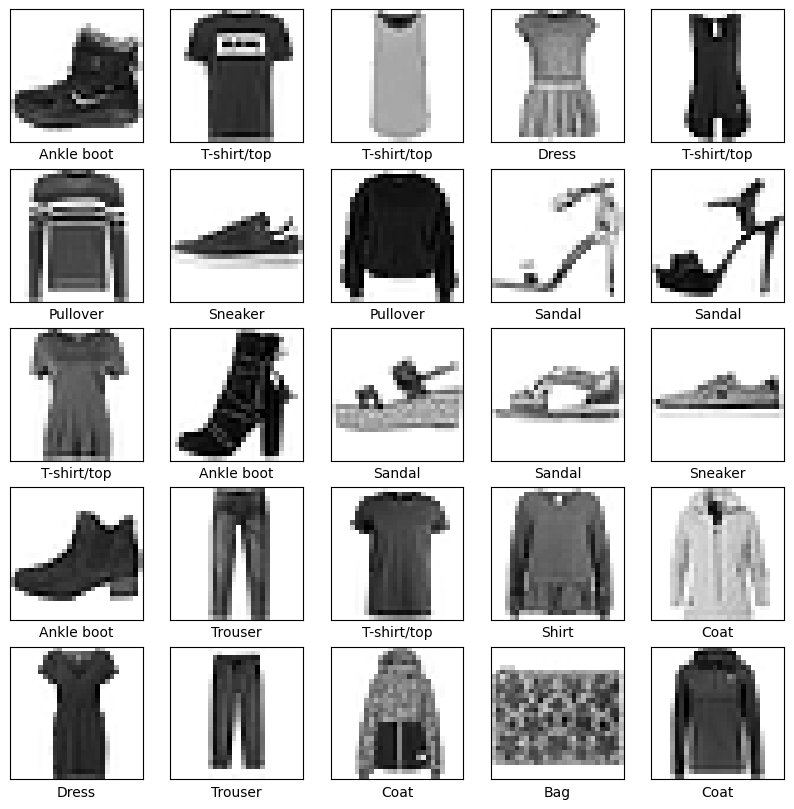

In [ ]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()   #Load the dataset here
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']   #These are the labels


# It is always good to see what type of data we are working on
# Write a code to generate following samples with their associated classes
# Write your code here


In [ ]:
# Images are 28x28. We don't plan to resize them now
IMG_HEIGHT=28
IMG_WIDTH= 28


In [ ]:
# Normalize inputs from 0-255 to 0-1
X_train =   #Write your code here
X_test =    #Write your code here


In [ ]:
#Create the model here. It should be an NN model with one hiddenlayer (128 nodes) and Relu activation function. What should be the output activation function?

loss_fn =   # Make your Loss function here. This is a classification problem


model = tf.keras.Sequential([ ])  # Fill in with appropriate values

model.compile(
    optimizer='adam',
    loss=loss_fn,
    metrics=['accuracy']
)

In [ ]:
# Train the model here
hist = model.fit()  # start trauining the model here. We have 20% for validation, 20 epochs and batch sizes are 128

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8181 - loss: 0.5188 - val_accuracy: 0.8512 - val_loss: 0.4328
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8612 - loss: 0.3833 - val_accuracy: 0.8674 - val_loss: 0.3747
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8742 - loss: 0.3429 - val_accuracy: 0.8700 - val_loss: 0.3609
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8852 - loss: 0.3181 - val_accuracy: 0.8746 - val_loss: 0.3448
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8897 - loss: 0.2977 - val_accuracy: 0.8743 - val_loss: 0.3462
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8958 - loss: 0.2836 - val_accuracy: 0.8817 - val_loss: 0.3284
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9001 - loss: 0.2716 - val_accuracy: 0.8692 - val_loss: 0.3661
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9029 - loss: 0.2596 - 

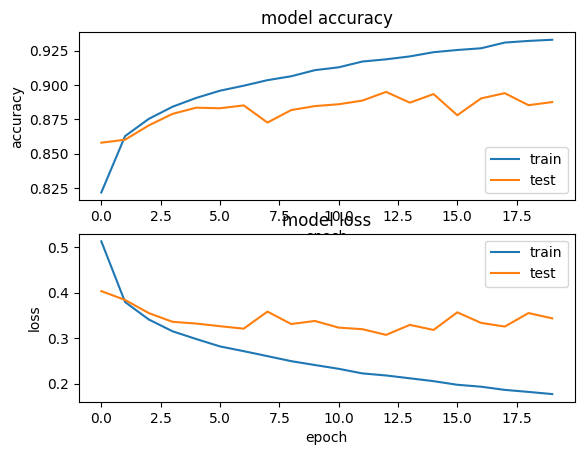

In [ ]:
# Draw the learning curve here


In [ ]:
# Write your understanding about this model here

**Part 2- Image Processing**

Load the Flower photo dataset from tensorflow repository

In [ ]:
import pathlib

search_root = pathlib.Path("/root/.keras/datasets/flower_photos")

#In case you cannot download the files automatically, you can download them from here:
#dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

# Find the folder that directly contains the flower-class folders
daisy_folders = [
    folder for folder in search_root.rglob("daisy")
    if folder.is_dir()
]

if not daisy_folders:
    raise FileNotFoundError("The extracted daisy folder could not be found.")

data_dir = daisy_folders[0].parent

image_count = len(list(data_dir.glob("*/*.jpg")))

# Print the number of images and the classes

Correct dataset directory: /root/.keras/datasets/flower_photos/flower_photos
Class folders: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Number of images: 3670


*a) How many images we can find in this dataset?*




*b) The list of subfolders are:*
*   daisy
*   dandelion
*   roses
*   sunflowers
*   tulips

You can look into any of the subfolders to see images stored over there. You can look into the folder using: data_dir.glob('tulips/*')
For this part use Pillow (PIL) to show at least one flower from each subfolder


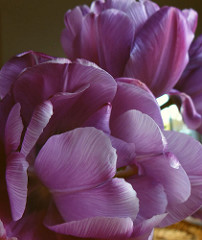

In [ ]:
tulips = list(data_dir.glob('tulips/*'))    #This line stores the list of data in subfolder
PIL.Image.open(str(tulips[14]))              # Use Pillow here to plot the image


*c) Use Keras to resize all the images into same dimension 180x180*

In [ ]:
batch_size = 32
img_height = 180
img_width = 180

In [ ]:
# Convert all the images in data_dir folder into 180x180 using tf.kera.utils.image_dataset_from_directory
# Modify following code
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


In [ ]:
# Use the same strategy to create validation data, this time from validation subset
val_ds =   # It is your turn now


Found 3670 files belonging to 5 classes.
Using 734 files for validation.


d) *You can use* `train_ds.class_names` *command to get the list of labels. Write a code to randomly show 9 images from training data while printing their label on top of the image.*

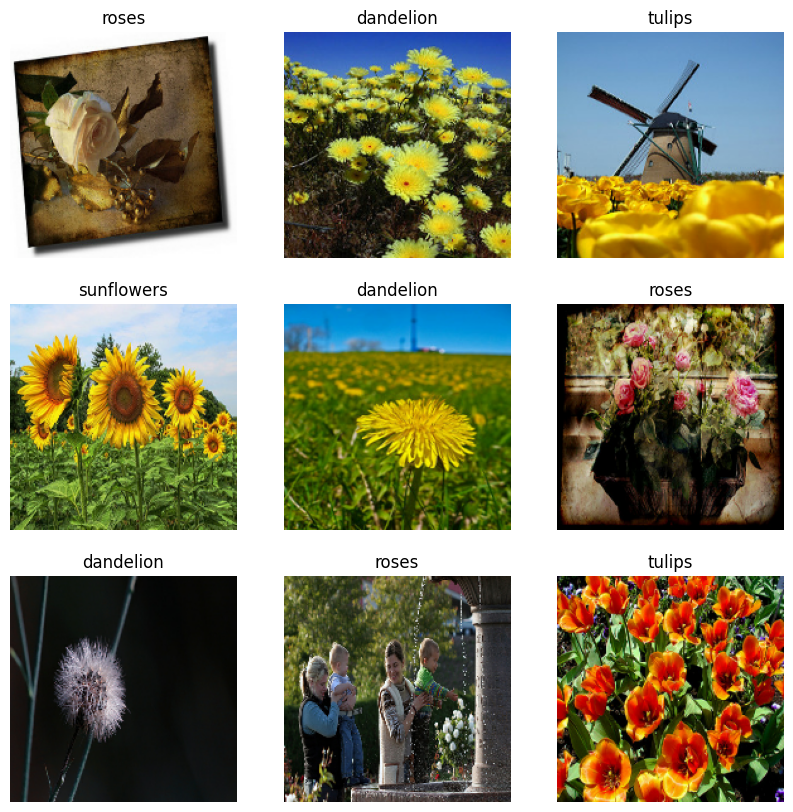

In [ ]:
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")

In [ ]:
# Please carefully review the images. What are some barriers that you can see in images for having a proper classification?

*e* - *Now, we want to use preprocessing package in Keras to apply different filters to the image. Apply the following procedures to image data:*
- *Rescale the image by dividing by 255*
- *Shear the image 20%*
- *Zoom the image 20%*
- *Horizontally flip the images*

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = # Write the code here to create above requested filters
training_set = train_datagen.flow_from_directory(data_dir, target_size = (180, 180), batch_size = 32)



Found 3670 images belonging to 5 classes.


**2- OPENCV**- Now use opencv for preprocessing. Show first 9 images in dataset using Opencv. Before showing each image, resize the images to 180x180.

<Figure size 1000x1000 with 0 Axes>

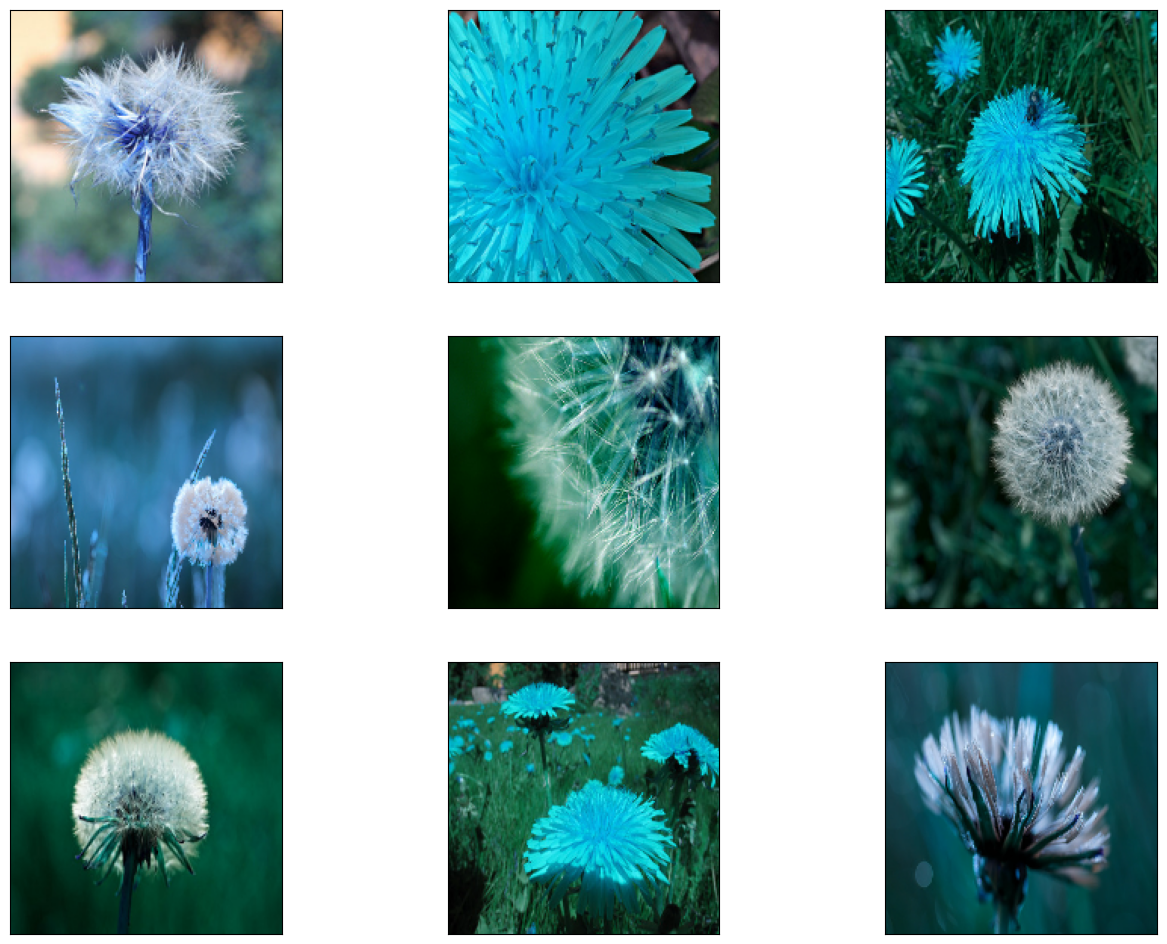

In [ ]:
# Repeat same preprocessing but this time using OpenCV. Show first 9 images in dataset using Opencv. Before showing each image, resize the images to 180x180.
import cv2
list_of_images= list(data_dir.glob('*/*.jpg'))
class_names = train_ds.class_names
plt.figure(figsize=(10, 10))
fig=plt.figure(figsize=(16, 12))

for i in range(9):
    y = plt.subplot(3, 3, i + 1)
    img = cv2.imread(str(list_of_images[i]))
    y.imshow(img)
    img = cv2.resize(img,(180,180))
    #img= cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    y.imshow(img)
    y.axes.get_xaxis().set_visible(False)
    y.axes.get_yaxis().set_visible(False)


plt.show()


OpenCV uses BGR as its default colour order for images, matplotlib uses RGB. When you display an image loaded with OpenCv in matplotlib the channels will be back to front.
The easiest way of fixing this is to use OpenCV to explicitly convert it back to RGB, much like you do when creating the greyscale image.


<Figure size 1000x1000 with 0 Axes>

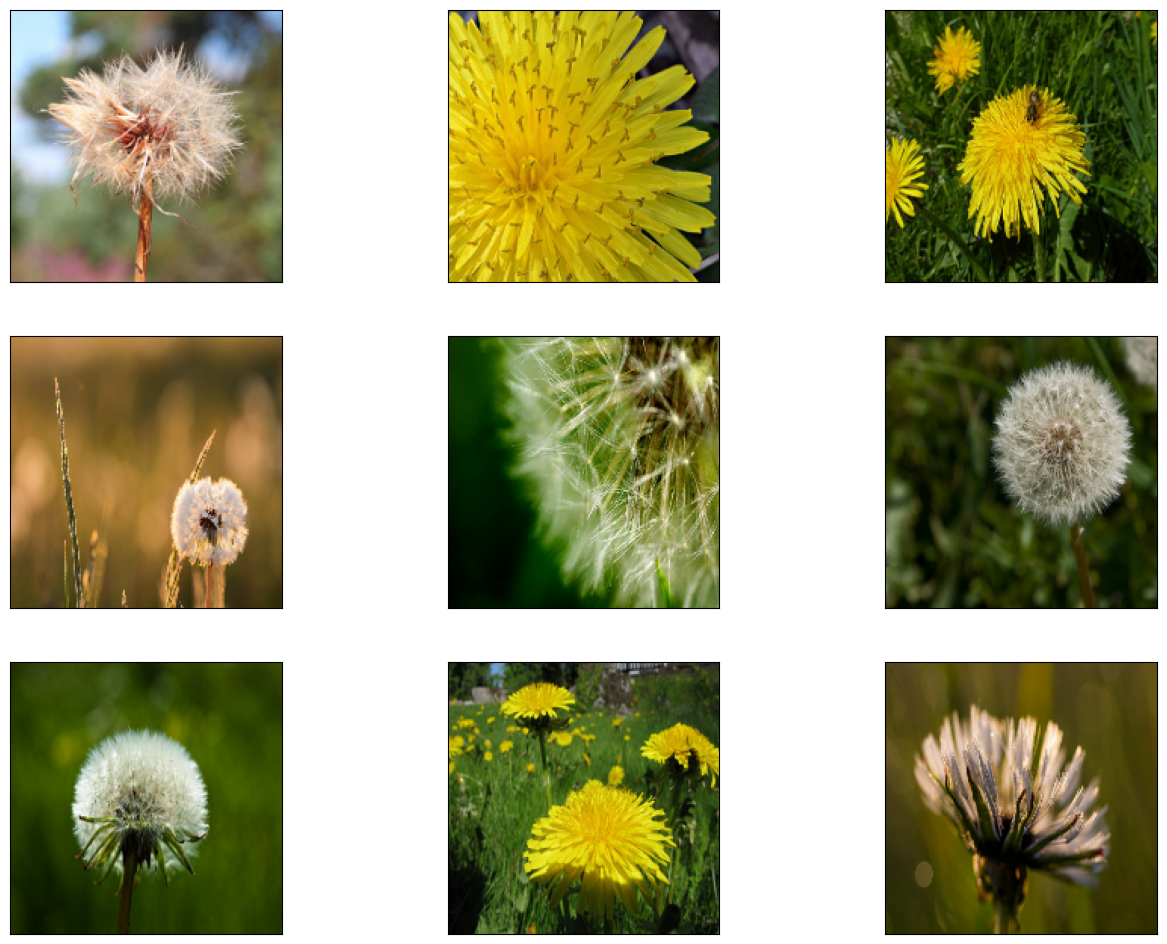

In [ ]:
# That was good but I need natural color so create the RGB version of above images.

This part onward is to create a pdf from this ipynb file. You can use these 3 cells throughout the semester tio create the pdf files.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono fonts-texgyre
  fonts-urw-base35 libapache-pom-java libcommons-logging-java libcommons-parent-java
  libfontbox-java libfontenc1 libgs9 libgs9-common libidn12 libijs-0.35 libjbig2dec0 libkpathsea6
  libpdfbox-java libptexenc1 libruby3.0 libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1
  libzzip-0-13 lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet ruby-rubygems
  ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils teckit tex-common tex-gyre
  texlive-base texlive-binaries texlive-fonts-recommended texlive-latex-base
  texlive-latex-recommended texlive-pictures texlive-plain-generic tipa xfonts-encodings
  xfonts-utils
Suggested packages:
  fo

In [ ]:
%shell jupyter nbconvert --to pdf '/content/drive/MyDrive/File_name.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Computer_Vision/Assignment_1_Solution.ipynb to pdf
[NbConvertApp] Support files will be in Assignment_1_Solution_files/
[NbConvertApp] Making directory ./Assignment_1_Solution_files
[NbConvertApp] Making directory ./Assignment_1_Solution_files
[NbConvertApp] Making directory ./Assignment_1_Solution_files
[NbConvertApp] Making directory ./Assignment_1_Solution_files
[NbConvertApp] Making directory ./Assignment_1_Solution_files
[NbConvertApp] Making directory ./Assignment_1_Solution_files
[NbConvertApp] Writing 72736 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 3374038 bytes to /content/drive/MyDrive/Computer_Vision/Assignment_1_Solution.p